In [1]:
# restart the kernel to resolve errors

In [2]:
!pip install scikit-learn==0.24.2
!pip install cloudpickle==2.1.0
!pip install imgaug==0.2.7
!pip install scipy==1.7.0
!pip3 install auto-sklearn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [3]:
# basics
import numpy as np
import pandas as pd
from pandas import DataFrame
import time

# machine learning
import sklearn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# bayesian optimization
import autosklearn
import autosklearn.classification as classifier

# ploting
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# simulated annealing
from drive.MyDrive.Advanced_Topics_in_Machine_Learning.simulated_annealing_module import simulated_annealing as sa

Mounted at /content/drive


In [5]:
# Generate 2-Class Classification Dataset
#X, y = make_classification(n_samples=200, n_classes=2, n_features=25)

X, y = make_classification(n_samples=500,
    n_features=20, n_redundant=2, n_informative=15, n_clusters_per_class=2, n_classes=2
)

X = pd.DataFrame(X)

In [ ]:
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (500, 20)
y shape: (500,)


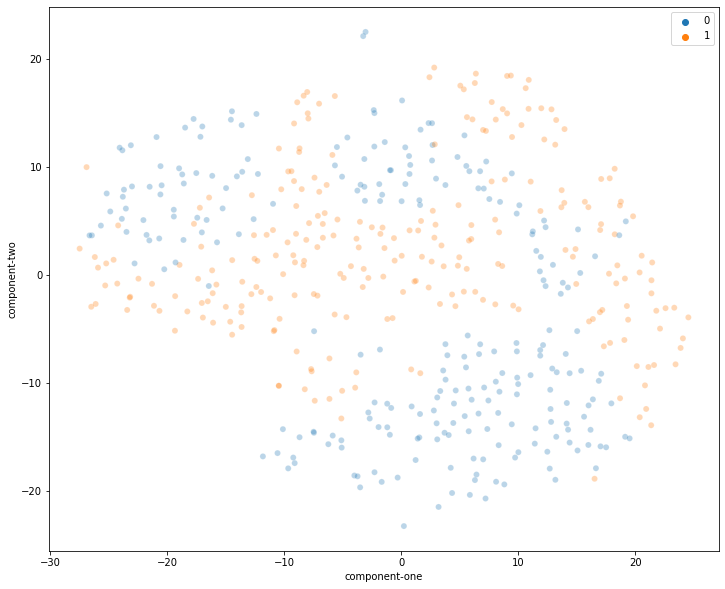

In [ ]:
tsne_data = X.copy()

# define t-sne model
tsne = TSNE(init='random',
            learning_rate=200.0,
            n_components=2,
            random_state=0)

tsne_results = tsne.fit_transform(tsne_data)

tsne_data['component-one'] = tsne_results[:,0]
tsne_data['component-two'] = tsne_results[:,1]

plt.figure(figsize=(12,10))
sns.scatterplot(x=tsne_data["component-one"], 
                y=tsne_data["component-two"],
                hue=y.ravel(),
                palette=sns.color_palette("tab10", n_colors=2),
                legend="full",
                alpha=0.3)

In [19]:
#do not run this cell (for now)
"""
===================================================================
Restricting the number of hyperparameters for an existing component
===================================================================
The following example demonstrates how to replace an existing
component with a new component, implementing the same classifier,
but with different hyperparameters .
"""

from ConfigSpace.configuration_space import ConfigurationSpace
from ConfigSpace.hyperparameters import UniformIntegerHyperparameter, UniformFloatHyperparameter, CategoricalHyperparameter

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import autosklearn.classification
import autosklearn.pipeline.components.classification
from autosklearn.pipeline.components.classification \
import AutoSklearnClassificationAlgorithm
from autosklearn.pipeline.constants import DENSE, UNSIGNED_DATA, PREDICTIONS, SPARSE

from sklearn.svm import SVC


############################################################################
# Subclass auto-sklearn's random forest classifier
# ================================================

# This classifier only has one of the hyperparameter's of auto-sklearn's
# default parametrization (``max_features``). Instead, it also
# tunes the number of estimators (``n_estimators``).

class CustomSVM(AutoSklearnClassificationAlgorithm):

    def __init__(self, C, gamma, kernel, random_state=None):
        print('init')
        self.C = C
        self.gamma = gamma
        self.random_state = random_state
        self.kernel = 'rbf'
        


    def fit(self, X, y, X_test, y_test):
        print('fit')
        self.estimator = SVC(
            C=self.C,
            gamma=self.gamma,
            kernel='rbf',
        )
        results = self.estimator.fit(X, y, X_test, y_test)
        print('Results')
        print(results)
        return self

    def predict(self, X):
        print('predict')
        if self.estimator is None:
            raise NotImplementedError()
        return self.estimator.predict(X)

    def predict_proba(self, X):
        print('predict_proba')
        if self.estimator is None:
            raise NotImplementedError()
        return self.estimator.predict_proba(X)

    @staticmethod
    def get_properties(dataset_properties=None):
        print('get_properties')
        return {
            'shortname': 'MySVM',
            'name': 'MySVMClassifier',
            'handles_regression': False,
            'handles_classification': True,
            'handles_multiclass': False,
            'handles_multilabel': False,
            'handles_multioutput': False,
            'is_deterministic': True,
            'input': (DENSE, SPARSE, UNSIGNED_DATA),
            'output': (PREDICTIONS,)
        }

    @staticmethod
    def get_hyperparameter_search_space(dataset_properties=None):
        print('get_hyperparameter_search_space')
        cs = ConfigurationSpace()

        # The maximum number of features used in the forest is calculated as m^max_features, where
        # m is the total number of features, and max_features is the hyperparameter specified below.
        # The default is 0.5, which yields sqrt(m) features as max_features in the estimator. This
        # corresponds with Geurts' heuristic.
        C = CategoricalHyperparameter('C', choices=[1e-3, 0.01, 0.1, 1, 2, 3, 4, 5,6,7,8,10,12,15,20,30,40,50,60,70,80,90,100])
        gamma = CategoricalHyperparameter('gamma', choices=[16,15,14,13,12,10,9,8,7,6,5,4,3,2,1,0.5,0.1,1e-2,1e-3,1e-4,1e-5,1e-6,1e-7])
        kernel = CategoricalHyperparameter('kernel', choices=['rbf'])


        cs.add_hyperparameters([C, gamma, kernel])
        return cs


# Add custom random forest classifier component to auto-sklearn.
autosklearn.pipeline.components.classification.add_classifier(CustomSVM)
cs = CustomSVM.get_hyperparameter_search_space()
print(cs)

############################################################################
# Data Loading
# ============

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y)

############################################################################
# Fit Support Vector classifier to the data
# ========================================

clf = autosklearn.classification.AutoSklearnClassifier(time_left_for_this_task=180,
                                                       #per_run_time_limit=10,
                                                       include={'classifier': ['CustomSVM'],
                                                                'feature_preprocessor': ["no_preprocessing"],
                                                                },
                                                       resampling_strategy= 'cv',
                                                       resampling_strategy_arguments={'folds':3},
                                                       metric=autosklearn.metrics.f1_macro,
                                                       ensemble_size=0,)
clf.fit(X_train, y_train, X_test, y_test)

############################################################################
# Print the configuration space
# =============================

# Observe that this configuration space only contains our custom random
# forest, but not auto-sklearn's ``random_forest``
cs = clf.get_configuration_space(X_train, y_train, X_test, y_test)
assert 'random_forest' not in str(cs)
print(cs)


clf.cv_results_['rank_test_scores']

get_properties
get_hyperparameter_search_space
Configuration space object:
  Hyperparameters:
    C, Type: Categorical, Choices: {0.001, 0.01, 0.1, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100}, Default: 0.001
    gamma, Type: Categorical, Choices: {16, 15, 14, 13, 12, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0.5, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 1e-07}, Default: 16
    kernel, Type: Categorical, Choices: {rbf}, Default: rbf

get_properties
get_properties
get_properties
get_properties
get_properties
get_properties
get_properties
get_hyperparameter_search_space
get_properties
get_properties
get_properties
get_hyperparameter_search_space
init
[WARNING] [2022-06-18 09:39:54,609:Client-AutoMLSMBO(1)::9a9332d0-eeea-11ec-80e2-0242ac1c0002] Configuration 176 not found
[WARNING] [2022-06-18 09:39:54,611:Client-AutoMLSMBO(1)::9a9332d0-eeea-11ec-80e2-0242ac1c0002] Configuration 476 not found
[WARNING] [2022-06-18 09:39:54,611:Client-AutoMLSMBO(1)::9a9332d0-eeea-11ec-80e2-

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1])

In [15]:
# do not run this cell (for now)
automclassifier = clf
rank_test_scores = automclassifier.cv_results_['rank_test_scores']
indexies =  list(range(len(rank_test_scores)))

rank_test_indexies = [idx for _,idx in sorted(zip(rank_test_scores,indexies))]
print(rank_test_indexies)

scores_with_rbf_kernel = []

for i, idx in enumerate(rank_test_indexies):
  print(f'> Rank {i+1} algorythm ---------------------')
  print(f'  Test Score: {automclassifier.cv_results_["mean_test_score"][idx]}')
  print(f'  Parameters:')
  # print(automclassifier.cv_results_['params'][idx])
  print(f"\tC: {automclassifier.cv_results_['params'][idx]['classifier:CustomSVM:C']}")
  print(f"\tgamma: {automclassifier.cv_results_['params'][idx]['classifier:CustomSVM:gamma']}")
  print(f"\tkernel: {automclassifier.cv_results_['params'][idx]['classifier:CustomSVM:kernel']}")
  print()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
> Rank 1 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 0.001
	gamma: 16
	kernel: rbf

> Rank 2 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 70
	gamma: 1
	kernel: rbf

> Rank 3 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 100
	gamma: 1e-07
	kernel: rbf

> Rank 4 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 3
	gamma: 1e-05
	kernel: rbf

> Rank 5 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 20
	gamma: 1e-05
	kernel: rbf

> Rank 6 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 30
	gamma: 7
	kernel: rbf

> Rank 7 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 30
	gamma: 10
	kernel: rbf

> Rank 8 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 50
	gamma: 0.5
	kernel: rbf

> Rank 9 algorythm ---------------------
  Test Score: 0.0
  Parameters:
	C: 1
	gamma: 12
	kernel: rbf

> Rank

In [5]:
rng = np.random.RandomState(0)

In [6]:
#clf = SVC(kernel='rbf', random_state=rng)

# clf= sa.Simulated_annealing(
#     baseClassifier=SVC(kernel='rbf'),
#     parameters_grid = {'C': [1e-3, 0.01, 0.1, 1, 2, 3, 4, 5,6,7,8,10,12,15,20,30],
#    'gamma': [8,7,6,5,4,3, 2,1, 0.5, 0.1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]},
#     # The initial trial solution for starting the algorithm.
#     # Note that these are the coordinates in the grid of hyper parameters.
#     # In this example it would be C = 0.1 and gamma = 1
#     initial_trial_solution=[1,1],
#     # Cross validation folds. In each iteration the algorithm performs a cross validated fit.
#     cv= 5,
#     max_iterations = 100,
#     # Initial temperature. The higher the temperature, the greatest the 'turbulence' in the trial solutions hyper params.
#     initTemp = 3000,
#     # Initial value for the disturbance factor. This controls the amount of the flunctuations of the hyper params on a given temperature.
#     init_c = 5,
#     # This factor is the temperature reduction factor. It controls the rate of cooling. Max is 1 (no temperature reduction at all)
#     a = 0.97)

param_dist = {'C': [1e-3, 0.01, 0.1, 1, 2, 3, 4, 5,6,7,8,
                    10,12,15,20,30,40,50,60,70,80,90,100],
              'gamma': [16,15,14,13,12,10,9,8,7,6,5,4,3,
                        2,1,0.5,0.1,1e-2,1e-3,1e-4,1e-5,1e-6,1e-7],
             }

grid_search_scores = []
halving_scores = []
annealing_scores = []
bayesian_optimization_scores = []

for i in range(100): #100
    n_samples = 500
    X, y = make_classification(n_samples=n_samples, n_features=20,
                               n_informative=15, n_clusters_per_class=2, n_classes=3)
    clf = SVC(kernel='rbf', 
              random_state=rng
             )
    
    print(f'Iteration {i}')

    # Grid Search
    gs = GridSearchCV(SVC(),
                      param_dist,
                      scoring=['f1_macro'],
                      refit='f1_macro',
                      verbose=0,
                      cv=3,
                      n_jobs=-1)
    gs.fit(X, y)
    
    gs_score = gs.best_score_

    # Halving Random Search
    hrs = HalvingRandomSearchCV(estimator=clf,
                                param_distributions=param_dist,
                                factor=2,
                                random_state=rng,
                                scoring='f1_macro',
                                cv=3
                               )
    hrs.fit(X,y)
    hrs_score = hrs.best_score_
    
    # Simulated Annealing Search
    # start = time.time()

    sas = sa.Simulated_annealing(baseClassifier=clf,
                                 parameters_grid=param_dist,
                                 initial_trial_solution=[1,1],
                                 cv= 3,
                                 max_iterations = 100,
                                 initTemp = 3000,
                                 init_c = 5,
                                 a = 0.97)
    results = sas.fit(X,y)
    sas_score = sas.get_params()['cost']

    # stop = time.time()
    # run_duration = stop - start
    # print(run_duration)

    # Bayesian optimization
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    
    running_time = 30
    automclassifier = classifier.AutoSklearnClassifier(time_left_for_this_task=running_time, #run_duration, # to run the same time as the simulated annealing
                                                       include = {'classifier': ["libsvm_svc"],
                                                                   # Choose from:
                                                                   # ['adaboost', 'bernoulli_nb', 'decision_tree', 'extra_trees', 'gaussian_nb',
                                                                   # 'gradient_boosting', 'k_nearest_neighbors', 'lda', 'liblinear_svc', 'libsvm_svc',
                                                                   # 'mlp', 'multinomial_nb', 'passive_aggressive', 'qda', 'random_forest', 'sgd']
                                                                   'feature_preprocessor': ["no_preprocessing"],
                                                                   # Choose from:
                                                                   # ['densifier', 'extra_trees_preproc_for_classification', 'fast_ica',
                                                                   # 'feature_agglomeration', 'kernel_pca', 'kitchen_sinks', 'liblinear_svc_preprocessor',
                                                                   # 'no_preprocessing', 'nystroem_sampler', 'pca', 'polynomial', 'random_trees_embedding',
                                                                   # 'select_percentile_classification', 'select_rates_classification', 'truncatedSVD']
                                                                   },
                                                       resampling_strategy= 'cv',
                                                       resampling_strategy_arguments={'folds':3},
                                                       metric=autosklearn.metrics.f1_macro,
                                                       ensemble_size=0,
                                                      )
    
    automclassifier.fit(X_train, y_train, X_test, y_test)
    
    # Short found models by test scores
    rank_test_scores = automclassifier.cv_results_['rank_test_scores']
    indexies =  list(range(len(rank_test_scores)))

    rank_test_indexies = [idx for _,idx in sorted(zip(rank_test_scores,indexies))]
    #print(rank_test_indexies)
    
    # Choose the best SVC(rbf) model found
    for idx in rank_test_indexies:
      if automclassifier.cv_results_['params'][idx]['classifier:libsvm_svc:kernel'] == 'rbf':
        bo_model = SVC(kernel='rbf',
                       C=automclassifier.cv_results_['params'][idx]['classifier:libsvm_svc:C'],
                       gamma=automclassifier.cv_results_['params'][idx]['classifier:libsvm_svc:gamma'], 
                       random_state=rng
                      )
        break

    bo_score = automclassifier.cv_results_["mean_test_score"][idx]

    # Append all new scores
    print(f'Halving Random:\t{hrs_score:.5f}')
    halving_scores.append(hrs_score)
    
    print(f'Simulated Annealing:\t{sas_score:.5f}')
    annealing_scores.append(sas_score)
    
    print(f'Grid Search:\t{gs_score:.5f}')
    grid_search_scores.append(gs_score)
    
    print(f'Bayesian Optimization:\t{bo_score:.5f}')
    bayesian_optimization_scores.append(bo_score)

    print()

Streaming output truncated to the last 5000 lines.
[WARNING] [2022-06-16 09:07:43,747:Client-AutoMLSMBO(1)::c77a1602-ed53-11ec-8122-0242ac1c0002] Configuration 143 not found
[WARNING] [2022-06-16 09:07:43,747:Client-AutoMLSMBO(1)::c77a1602-ed53-11ec-8122-0242ac1c0002] Configuration 270 not found
[WARNING] [2022-06-16 09:07:43,747:Client-AutoMLSMBO(1)::c77a1602-ed53-11ec-8122-0242ac1c0002] Configuration 310 not found
[WARNING] [2022-06-16 09:07:43,747:Client-AutoMLSMBO(1)::c77a1602-ed53-11ec-8122-0242ac1c0002] Configuration 486 not found
[WARNING] [2022-06-16 09:07:43,747:Client-AutoMLSMBO(1)::c77a1602-ed53-11ec-8122-0242ac1c0002] Configuration 553 not found
[WARNING] [2022-06-16 09:07:43,747:Client-AutoMLSMBO(1)::c77a1602-ed53-11ec-8122-0242ac1c0002] Configuration 243 not found
[WARNING] [2022-06-16 09:07:43,747:Client-AutoMLSMBO(1)::c77a1602-ed53-11ec-8122-0242ac1c0002] Configuration 293 not found
[WARNING] [2022-06-16 09:07:43,747:Client-AutoMLSMBO(1)::c77a1602-ed53-11ec-8122-0242ac1

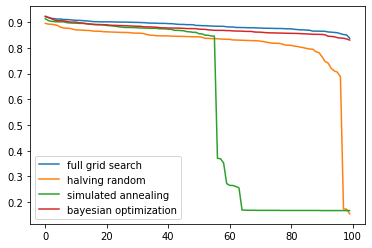

In [7]:
x_axis = list(range(0, len(grid_search_scores)))
grid_search_scores.sort(reverse=True)
halving_scores.sort(reverse=True)
annealing_scores.sort(reverse=True)
bayesian_optimization_scores.sort(reverse=True)

plt.plot(x_axis, grid_search_scores, label= "full grid search")
plt.plot(x_axis, halving_scores, label = "halving random")
plt.plot(x_axis, annealing_scores, label = "simulated annealing")
plt.plot(x_axis, bayesian_optimization_scores, label = "bayesian optimization")
plt.legend()
#plt.savefig(f'C:/Users/loufa/Desktop/Avanced_Topics_in_ML/compere_graph.png')
plt.savefig(f'drive/MyDrive/Advanced_Topics_in_Machine_Learning/compere_graph_{running_time}sec_{n_samples}_samples.png')
plt.show()